# Week 6 — Denoising Autoencoder on MNIST
**Name:** Amey Khodke <br> 
**Project:** Build a Deep Learning model that removes noise from images using a Denoising Autoencoder on the MNIST dataset.

---
# Import Libraries

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

np.random.seed(21)
tf.random.set_seed(21)

---
# Load Dataset and Preprocessing

In [16]:
TRAIN_DIR = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training"
TEST_DIR = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing"

def load_folder(path, img_size=28):
    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        labels=None,
        color_mode="grayscale",
        image_size=(img_size, img_size),
        batch_size=512,
        shuffle=False,
    )
    imgs = np.concatenate([b.numpy() for b in ds], axis=0)
    return imgs.astype("float32") / 255.0

x_train = load_folder(TRAIN_DIR)
x_test = load_folder(TEST_DIR)

print("train:", x_train.shape)
print("test :", x_test.shape)

Found 60000 files.
Found 10000 files.
train: (60000, 28, 28, 1)
test : (10000, 28, 28, 1)


---
# Add Noise

In [17]:
noise_factor = 0.35

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0, 1).astype("float32")
x_test_noisy = np.clip(x_test_noisy, 0, 1).astype("float32")

# Visualize

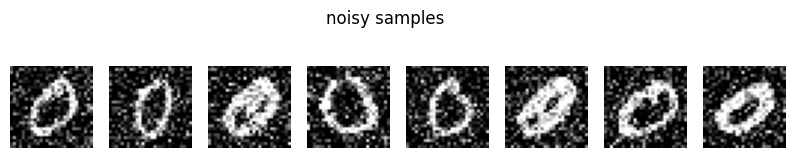

In [18]:
plt.figure(figsize=(10, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("noisy samples")
plt.show()

---
# Build Autoencoder


In [19]:
inp = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(16, 3, activation="relu", padding="same")(inp)
x = layers.MaxPooling2D(2, padding="same")(x)
x = layers.Conv2D(8, 3, activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D(2, padding="same")(x)

x = layers.Conv2D(8, 3, activation="relu", padding="same")(encoded)
x = layers.UpSampling2D(2)(x)
x = layers.Conv2D(16, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(2)(x)
decoded = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

autoencoder = Model(inp, decoded)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

---
# Model Summary

In [20]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

---
# Compile and Train Model

In [21]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - loss: 0.2021 - val_loss: 0.1146
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - loss: 0.1085 - val_loss: 0.1030
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - loss: 0.1021 - val_loss: 0.0992
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - loss: 0.0991 - val_loss: 0.0968
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - loss: 0.0971 - val_loss: 0.0952
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - loss: 0.0955 - val_loss: 0.0938
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - loss: 0.0943 - val_loss: 0.0928
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - loss: 0.0934 - val_loss: 0.0920
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - loss: 0.0926 - val_loss: 0.0913
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - loss: 0.0919 - val_loss: 0.0908


---
# Loss curve

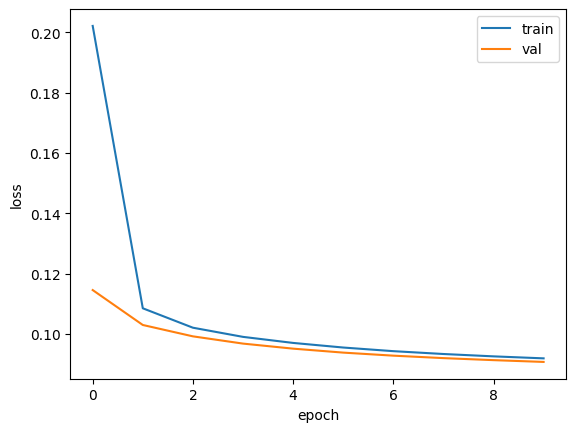

In [22]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

---
# Evaluate Model
Evaluate the autoencoder on the test set and compute the **Mean Squared Error (MSE)** between original and reconstructed images.

In [23]:
decoded_imgs = autoencoder.predict(x_test_noisy)

mse = np.mean((x_test - decoded_imgs) ** 2)
print("MSE:", mse)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
MSE: 0.009453925


---
# Visualize Reconstruction

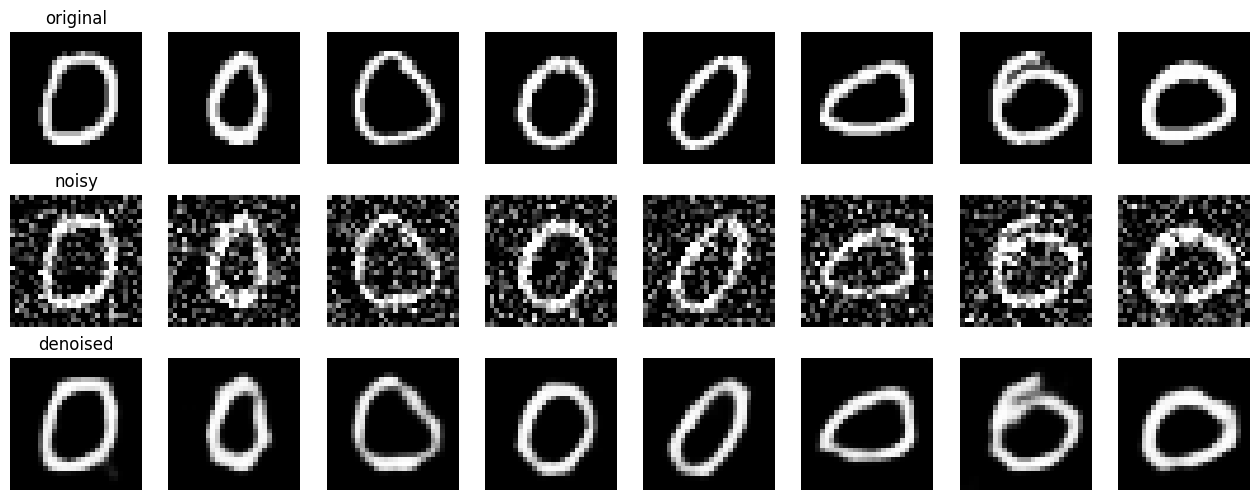

In [24]:
n = 8
plt.figure(figsize=(16, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("original")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("noisy")

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("denoised")

plt.show()

## Observations

- The autoencoder removes most of the noise and gives back a readable digit.
- Output is a bit blurry compared to the original since the middle layer compresses the image a lot.
- Train and validation loss go down together, so it isn't overfitting.
- MSE on the test set is small, which matches what the images show.

## Conclusion

Built a simple convolutional autoencoder that learns to map noisy MNIST digits back to their clean versions, using the PNG image dataset from Kaggle. It compresses each image down through a couple of Conv+Pooling layers and then reconstructs it with Conv+Upsampling layers. The loss curves and low MSE both show the model generalizes well, and the denoised outputs look close to the originals apart from some minor blurring.